# 01 数据读取、固定划分与多路线预处理

对应参考仓库 `Highspectrum.ipynb` / `HybridSN.ipynb` 的数据处理顺序，但修正了其中的硬编码路径、外部特征文件依赖和数据泄漏风险。支持 Pavia University、Indian Pines、Salinas 三套 `.mat` 数据。

本 Notebook 的唯一随机协议：**按类别分层 24% 训练、6% 验证、70% 测试，seed=1442**。划分文件一旦生成，后续模型不再重新抽样。


In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (cwd, *cwd.parents) if (path / "src").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
SEED = 1442
print("PROJECT_ROOT =", PROJECT_ROOT)
print("frozen random seed =", SEED)


PROJECT_ROOT = G:\高光谱智能图像解译\hsi_project
frozen random seed = 1442


## 0. 环境、数据集与路径配置验证


In [2]:
from src.coursework.stage1 import load_stage1_config, route_config, run_stage1
from src.datasets.高光谱预处理 import load_hsi_data
from src.datasets.数据集注册 import DATASETS

DATASET_KEY = "pavia_university"  # 可改为 indian_pines / salinas
RUN_STAGE1 = False                 # True 会重新拟合并覆盖确定性 stage1 输出
CONFIG_PATH = PROJECT_ROOT / f"coursework/configs/stage1_data/{DATASET_KEY}.yaml"
OUTPUT_DIR = PROJECT_ROOT / f"coursework/outputs/stage1/{DATASET_KEY}"
values = load_stage1_config(CONFIG_PATH)
checks = []
for key, spec in DATASETS.items():
    checks.append({
        "dataset": key,
        "cube_file": spec.data_file,
        "cube_exists": (PROJECT_ROOT / "data/raw" / spec.data_file).is_file(),
        "label_file": spec.label_file,
        "label_exists": (PROJECT_ROOT / "data/raw" / spec.label_file).is_file(),
        "classes": len(spec.class_names),
    })
pd.DataFrame(checks)


,dataset,cube_file,cube_exists,label_file,label_exists,classes
0,pavia_university,PaviaU.mat,True,PaviaU_gt.mat,True,9
1,indian_pines,Indian_pines_corrected.mat,True,Indian_pines_gt.mat,True,16
2,salinas,Salinas_corrected.mat,True,Salinas_gt.mat,True,16


## 1. 数据集加载与简单取样


cube: (610, 340, 103) uint16
label map: (610, 340) uint8
labeled pixels: 42776
sample identity: {'sample_index': 13, 'coordinate': (0, 170), 'raw_label': 4}


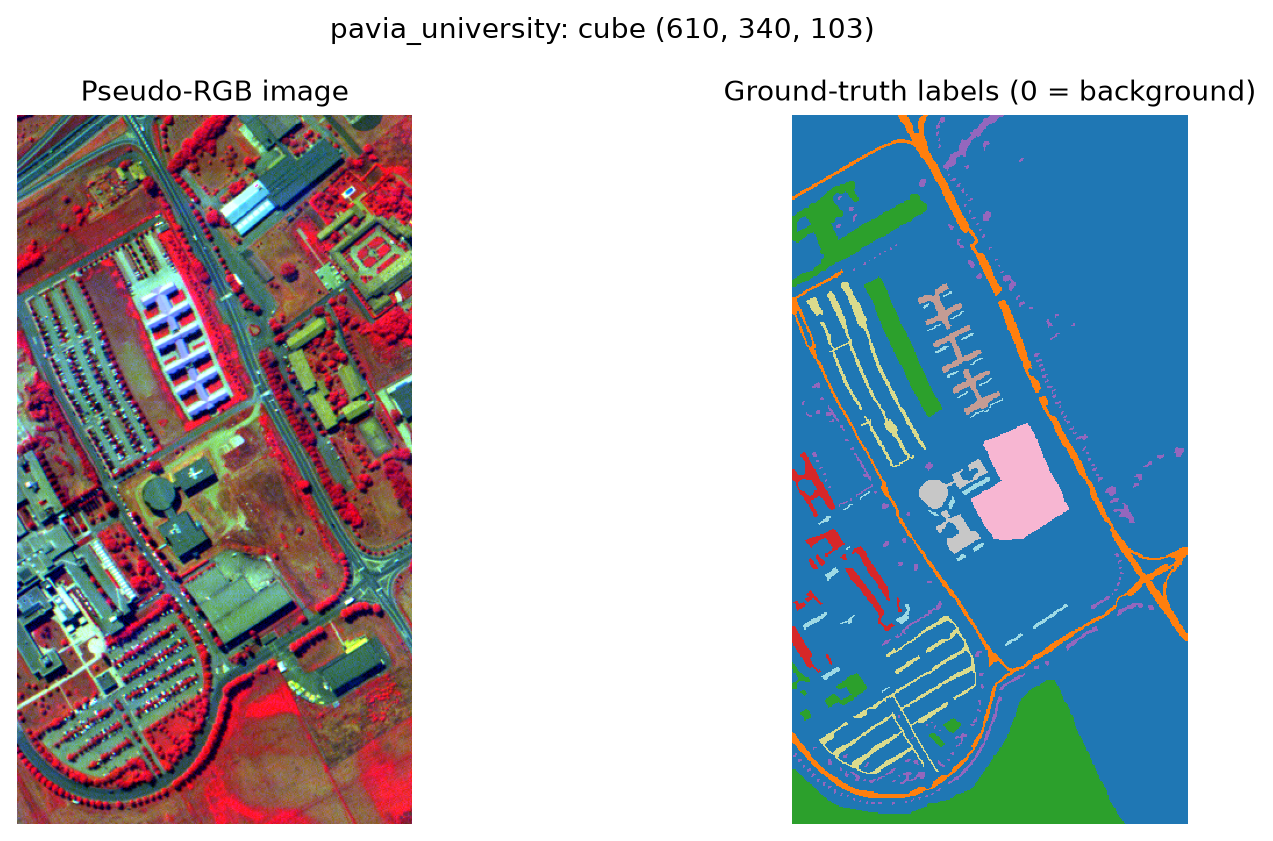

In [3]:
selected_config = route_config(values, values["selected_route"])
data = load_hsi_data(PROJECT_ROOT, selected_config)
print("cube:", data.cube.shape, data.cube.dtype)
print("label map:", data.label_map.shape, data.label_map.dtype)
print("labeled pixels:", data.labels.size)
first = data.train_indices[0]
row, col = data.coordinates[first]
print("sample identity:", {"sample_index": int(first), "coordinate": (int(row), int(col)), "raw_label": int(data.labels[first])})
display(Image(filename=str(OUTPUT_DIR / "figures/01_dataset_overview.png")))


## 2. 数据集构成分析


,class_id,class_name,total,train,validation,test
0,1,Asphalt,6631,1591,398,4642
1,2,Meadows,18649,4475,1119,13055
2,3,Gravel,2099,504,126,1469
3,4,Trees,3064,735,184,2145
4,5,Painted metal sheets,1345,323,80,942
5,6,Bare Soil,5029,1207,302,3520
6,7,Bitumen,1330,319,80,931
7,8,Self-Blocking Bricks,3682,884,221,2577
8,9,Shadows,947,227,57,663


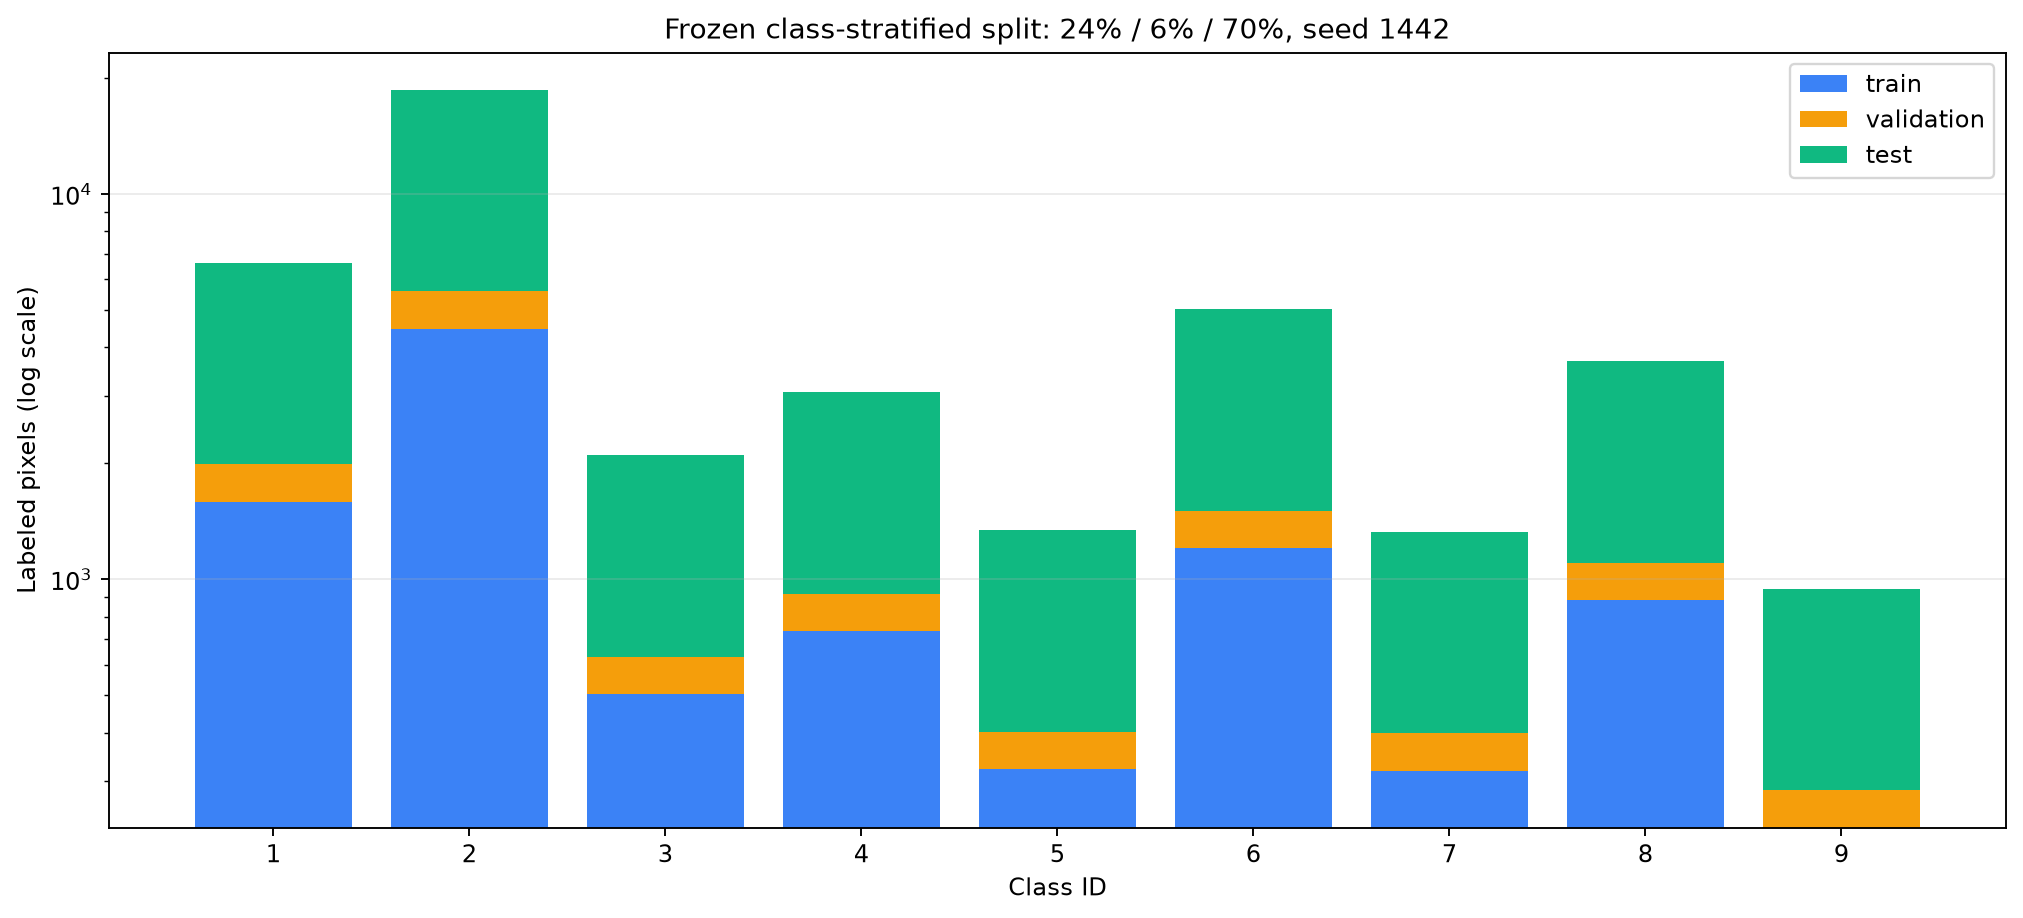

In [4]:
records = []
for class_id, class_name in enumerate(data.spec.class_names, start=1):
    row = {"class_id": class_id, "class_name": class_name, "total": int(np.sum(data.labels == class_id))}
    for split_name, indices in data.indices_by_split.items():
        row[split_name] = int(np.sum(data.labels[indices] == class_id))
    records.append(row)
composition = pd.DataFrame(records)
display(composition)
display(Image(filename=str(OUTPUT_DIR / "figures/02_class_and_split_distribution.png")))


## 3. 固定数据划分（后续禁止改动）

参考仓库常用 30%/70% 训练测试口径。为了让超参数选择不接触测试集，把 30% 建模池再按 80%/20% 分为训练/验证，得到 24%/6%/70%。这是分层的**像元级随机划分**，三组互斥并覆盖全部有标签像元。


In [5]:
split_rows = []
assigned = []
for split_name, indices in data.indices_by_split.items():
    assigned.append(indices)
    split_rows.append({"split": split_name, "samples": len(indices), "actual_fraction": len(indices) / len(data.labels)})
assigned = np.concatenate(assigned)
assert np.unique(assigned).size == data.labels.size
assert np.array_equal(np.sort(assigned), np.arange(data.labels.size))
assert int(data.split_metadata["protocol"]["seed"]) == 1442
pd.DataFrame(split_rows)


,split,samples,actual_fraction
0,train,10265,0.239971
1,validation,2567,0.060010
2,test,29944,0.700019


## 4. 原始波段、PCA、LDA 与波段选择


In [6]:
route_table = []
for key, route in values["routes"].items():
    route_table.append({"route": key, **route})
pd.DataFrame(route_table).fillna("")


,route,standardization,reducer,n_components,whiten,method
0,raw_all_bands,standard,none,,,
1,pca15,standard,pca,15.0,False,
2,lda8,standard,lda,8.0,,
3,uniform15,standard,band_selection,15.0,,uniform
4,fisher15,standard,band_selection,15.0,,fisher


- `raw_all_bands`：不降维，保留全谱；仍用训练集统计量逐波段标准化。
- `pca15`：无监督线性降维；仅用训练中心像元拟合。
- `lda8/lda15`：有监督投影，上限为类别数减一；仅用训练标签拟合。
- `uniform15`：按波段序号均匀保留，标签无关。
- `fisher15`：只用训练标签计算 Fisher 分数，选出判别性最高的原始波段。


,route,standardization,reducer,band_selection_method,input_bands,output_bands,fit_and_transform_seconds,cumulative_explained_variance_ratio,supervised_fit,validation_or_test_used_for_fit,selected_band_numbers_one_based
0,raw_all_bands,standard,none,NaN,103,103,1.889452,NaN,False,False,NaN
1,pca15,standard,pca,NaN,103,15,2.340980,0.999236,False,False,NaN
2,lda8,standard,lda,NaN,103,8,1.268530,1.000000,True,False,NaN
3,uniform15,standard,band_selection,uniform,103,15,0.326994,NaN,False,False,"[1, 8, 16, 23, 30, 37, 45, 52, 59, 67, 74, 81,..."
4,fisher15,standard,band_selection,fisher,103,15,0.323793,NaN,True,False,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ..."


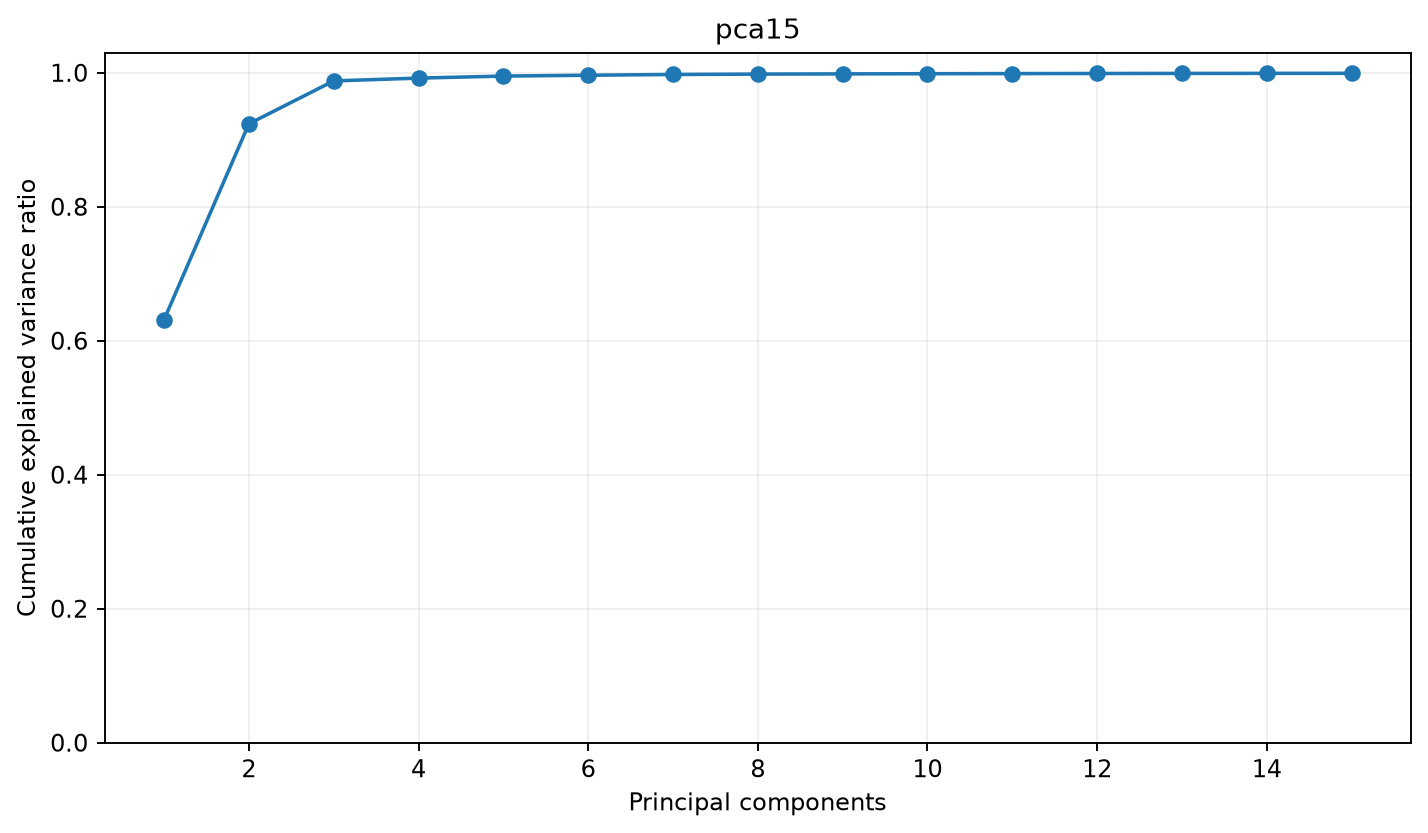

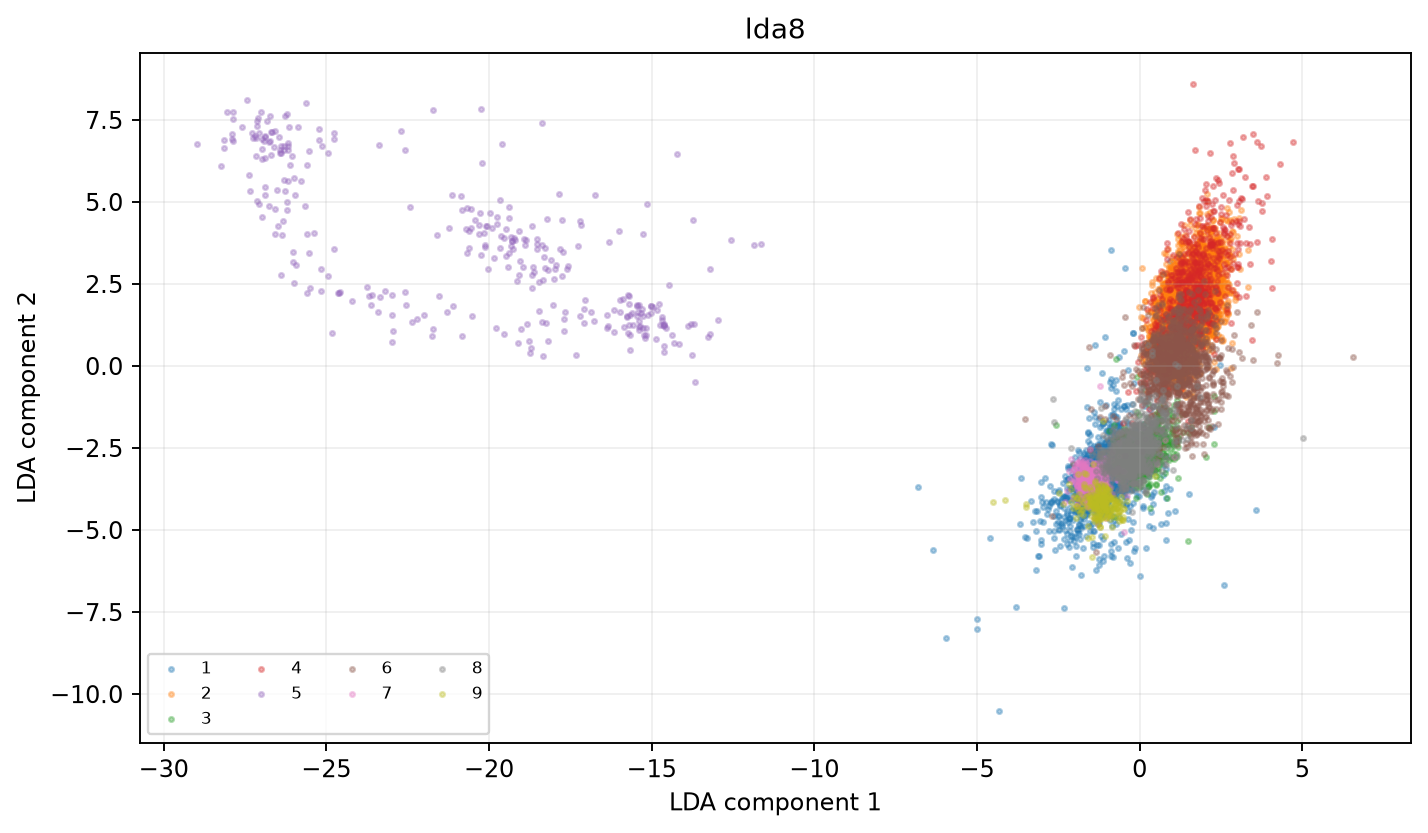

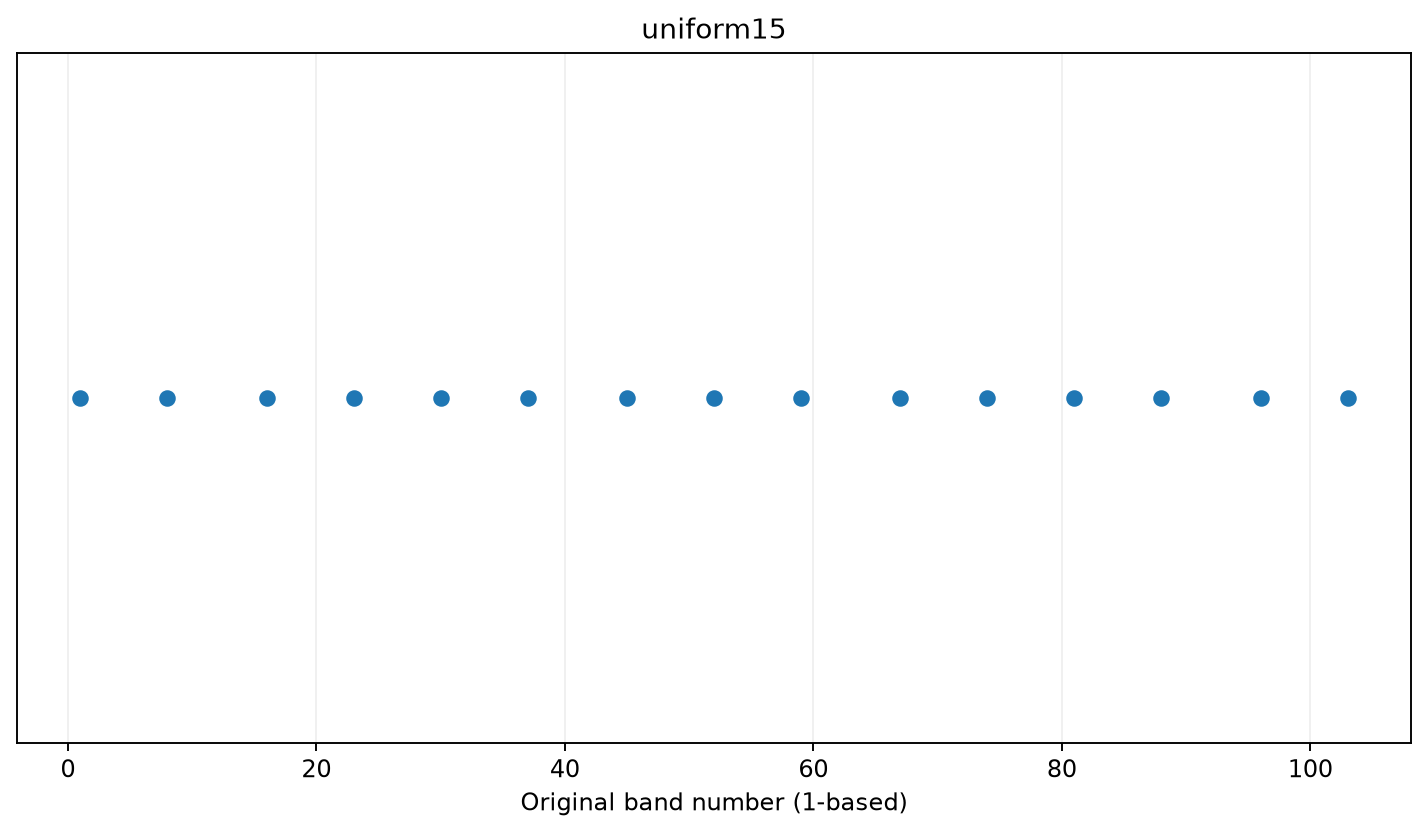

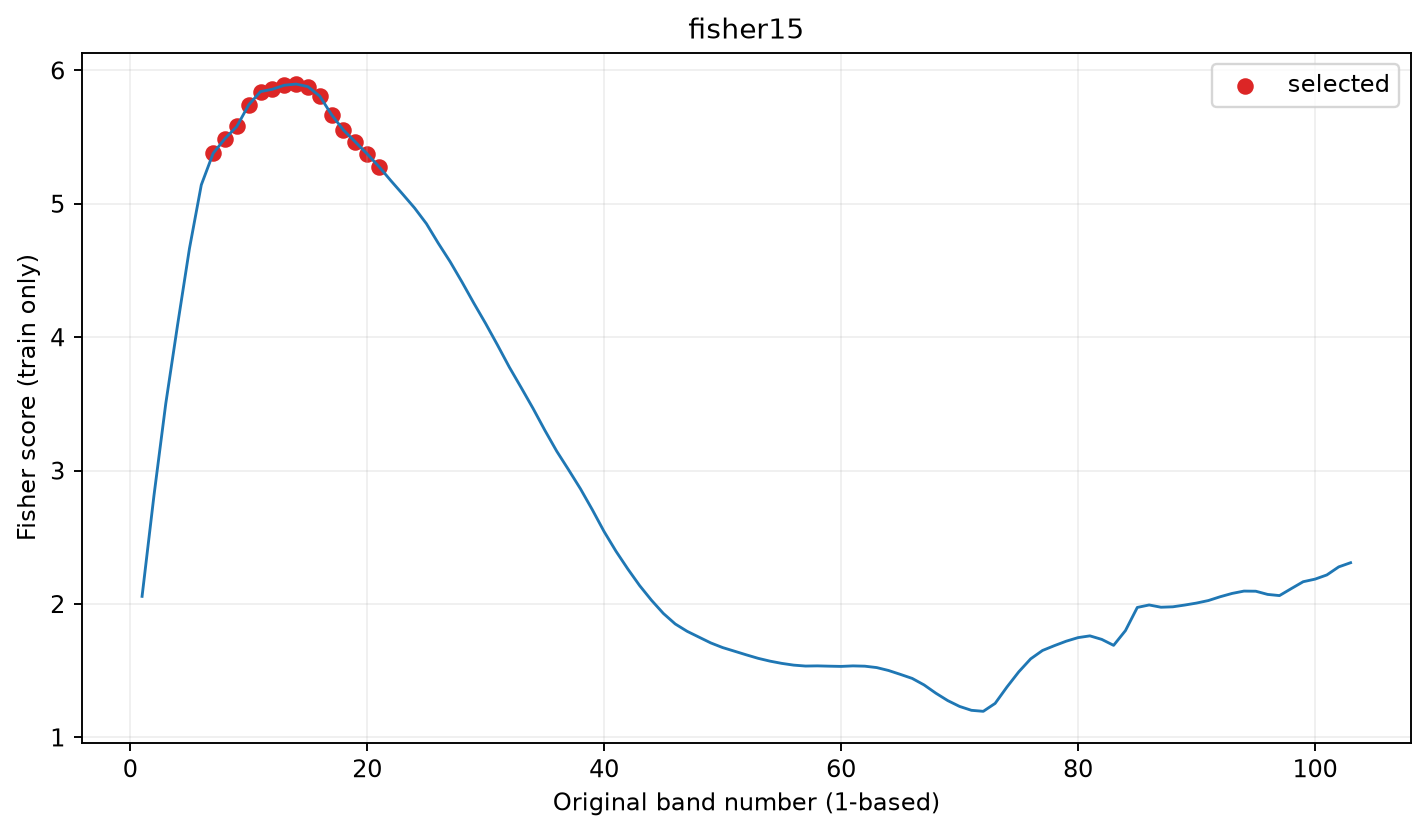

In [7]:
if RUN_STAGE1:
    stage1_result = run_stage1(PROJECT_ROOT, CONFIG_PATH, OUTPUT_DIR, overwrite=True)
manifest = json.loads((OUTPUT_DIR / "stage1_manifest.json").read_text(encoding="utf-8"))
route_summary = pd.read_csv(OUTPUT_DIR / "preprocessing_route_summary.csv")
display(route_summary)
for name in ("route_pca15.png", "route_lda8.png", "route_uniform15.png", "route_fisher15.png"):
    path = OUTPUT_DIR / "figures" / name
    if path.is_file():
        display(Image(filename=str(path), width=720))


## 5. 阶段一交接文件


In [8]:
handoff = manifest["selected_artifact"]
print("selected route:", manifest["selected_route"])
print("model-ready NPZ:", PROJECT_ROOT / handoff["model_ready"])
print("preprocessing state:", PROJECT_ROOT / handoff["state"])
print("effective YAML:", OUTPUT_DIR / "selected_preprocessing.yaml")
assert manifest["frozen_protocol"]["immutable_for_downstream_experiments"] is True
assert manifest["frozen_protocol"]["seed"] == 1442
handoff


selected route: pca15
model-ready NPZ: G:\高光谱智能图像解译\hsi_project\coursework\outputs\stage1\pavia_university\routes\pca15\model_ready_dataset.npz
preprocessing state: G:\高光谱智能图像解译\hsi_project\coursework\outputs\stage1\pavia_university\routes\pca15\preprocessing_state.npz
effective YAML: G:\高光谱智能图像解译\hsi_project\coursework\outputs\stage1\pavia_university\selected_preprocessing.yaml


{'config': {'dataset_name': 'pavia_university',
  'split_protocol': 'fair24_6_70',
  'split_seed': 1442,
  'standardization': 'standard',
  'reducer': 'pca',
  'n_components': 15,
  'whiten': False,
  'band_selection_method': 'fisher',
  'representation': 'patch',
  'patch_size': 25,
  'padding_mode': 'constant',
  'padding_value': 0.0,
  'output_dtype': 'float32'},
 'config_fingerprint': '136155690f4b132175e0ccb9e93aa88a7a69e5cb7ca3e14be898271c76e55284',
 'state': 'coursework\\outputs\\stage1\\pavia_university\\routes\\pca15\\preprocessing_state.npz',
 'metadata': 'coursework\\outputs\\stage1\\pavia_university\\routes\\pca15\\metadata.json',
 'model_ready': 'coursework\\outputs\\stage1\\pavia_university\\routes\\pca15\\model_ready_dataset.npz'}

## 任务性质的准确解释

高光谱数据不是“一堆没有空间关系的点”，而是一个 `H×W×B` 数据立方体：每个二维位置是一个像元，每个像元有长度为 `B` 的光谱向量。标签图只给部分像元赋类别，0 表示未标注背景。

本课题的学习单位是**有标签中心像元**：传统方法读取中心像元光谱并可拼接 LBP/Gabor 邻域特征；HybridSN 读取以该像元为中心的 `25×25×B` patch，输出中心像元的一个地物类别。因此它是“高光谱像元分类 / patch-based dense classification”，可以生成与语义分割相似的分类图，但**不是标准端到端语义分割**：模型并非一次输入整幅图并输出每个位置的掩膜，训练/测试也按有标签像元抽样。分类图中未标注区域没有可用于定量评价的真值。
